In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.feature_selection import SequentialFeatureSelector

In [68]:
# LOAD DATASET 
df = pd.read_csv("healthcare.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (200, 12)
   patient_id  age  gender  height_cm  weight_kg  blood_pressure  cholesterol  \
0           1   58    Male        167         75              95          169   
1           2   71    Male        151         83             158          262   
2           3   48    Male        184         90             136          289   
3           4   34  Female        165         56             114          196   
4           5   62  Female        185         53             155          150   

   heart_rate  glucose_level  smoking  exercise_hours  disease_risk  
0          89            158        0               5     80.322988  
1          82             81        1               2    116.465039  
2          78             84        1               8    105.730794  
3          91            128        1               4     88.970408  
4          89             95        0               2     89.468219  


In [69]:
# DATA PREPROCESSING
df = df.drop('patient_id', axis=1)

# Convert categorical features into numeric
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.mean())


In [70]:
y = df["disease_risk"]              # Target
X = df.drop("disease_risk", axis=1) # Feature 

In [71]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [72]:
# FEATURE SCALING (for kNN)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
# linear regression
lr = LinearRegression()

In [74]:
# Forward Selection using Linear Regression
print("\n--- Forward Feature Selection(Linear Regression) ---")


sfs_lr_forward = SequentialFeatureSelector(lr, n_features_to_select=5, direction="forward")
sfs_lr_forward.fit(X_train, y_train)
lr_forward_features = X.columns[sfs_lr_forward.get_support()]


# Evaluate Linear Regression Model
lr.fit(X_train[lr_forward_features], y_train)
lr_pred = lr.predict(X_test[lr_forward_features])
lr_forward_r2 = r2_score(y_test, lr_pred)


print("LR Features:", list(lr_forward_features))
print("LR R2:", lr_forward_r2)


--- Forward Feature Selection(Linear Regression) ---
LR Features: ['age', 'height_cm', 'blood_pressure', 'cholesterol', 'glucose_level']
LR R2: 0.5994722682596416


In [75]:
# KNN
knn = KNeighborsRegressor(n_neighbors=5)

In [76]:
# Forward Selection using kNN
print("\n--- Forward Feature Selection(kNN) ---")
sfs_knn_forward = SequentialFeatureSelector(knn, n_features_to_select=5, direction="forward")
sfs_knn_forward.fit(X_train_scaled, y_train)
knn_forward_features = X.columns[sfs_knn_forward.get_support()]


# Evaluate kNN Model
knn.fit(X_train_scaled[:, sfs_knn_forward.get_support()], y_train)
knn_pred = knn.predict(X_test_scaled[:, sfs_knn_forward.get_support()])
knn_forward_r2 = r2_score(y_test, knn_pred)


print("kNN Features:", list(knn_forward_features))
print("kNN R2:", knn_forward_r2)


--- Forward Feature Selection(kNN) ---
kNN Features: ['age', 'blood_pressure', 'cholesterol', 'glucose_level', 'exercise_hours']
kNN R2: 0.2798892118967774


In [77]:
# Backward Elimination using Linear Regression

print("\n--- Backward Feature Elimination(Linear Regression) ---")


sfs_lr_backward = SequentialFeatureSelector(lr, n_features_to_select=5, direction="backward")
sfs_lr_backward.fit(X_train, y_train)
lr_backward_features = X.columns[sfs_lr_backward.get_support()]


# Evaluate Linear Regression Model
lr.fit(X_train[lr_backward_features], y_train)
lr_pred = lr.predict(X_test[lr_backward_features])
lr_backward_r2 = r2_score(y_test, lr_pred)

print("LR Features:", list(lr_backward_features))
print("LR R2:", lr_backward_r2)




--- Backward Feature Elimination(Linear Regression) ---
LR Features: ['age', 'height_cm', 'blood_pressure', 'cholesterol', 'glucose_level']
LR R2: 0.5994722682596416


In [83]:
# Backward Elimination using kNN
print("\n--- Backward Feature Elimination(kNN) ---")
sfs_knn_backward = SequentialFeatureSelector(knn, n_features_to_select=5, direction="backward")
sfs_knn_backward.fit(X_train_scaled, y_train)
knn_backward_features = X.columns[sfs_knn_backward.get_support()]

# Evaluate kNN Model
knn.fit(X_train_scaled[:, sfs_knn_backward.get_support()], y_train)
knn_pred = knn.predict(X_test_scaled[:, sfs_knn_backward.get_support()])
knn_backward_r2 = r2_score(y_test, knn_pred)

print("kNN Features:", list(knn_backward_features))
print("kNN R2:", knn_backward_r2)


--- Backward Feature Elimination(kNN) ---
kNN Features: ['age', 'blood_pressure', 'cholesterol', 'smoking', 'exercise_hours']
kNN R2: 0.4018903227991013


In [79]:
# COMPARE FEATURE SETS
print("\n--- Final Comparison ---")

print("\nLinear Regression:")
print("Forward:", list(lr_forward_features))
print("Backward:", list(lr_backward_features))

print("\nkNN:")
print("Forward:", list(knn_forward_features))
print("Backward:", list(knn_backward_features))



--- Final Comparison ---

Linear Regression:
Forward: ['age', 'height_cm', 'blood_pressure', 'cholesterol', 'glucose_level']
Backward: ['age', 'height_cm', 'blood_pressure', 'cholesterol', 'glucose_level']

kNN:
Forward: ['age', 'blood_pressure', 'cholesterol', 'glucose_level', 'exercise_hours']
Backward: ['age', 'blood_pressure', 'cholesterol', 'smoking', 'exercise_hours']


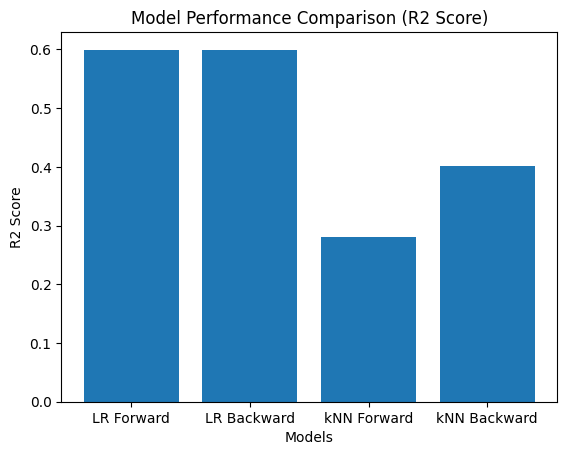

In [80]:
models = ['LR Forward', 'LR Backward', 'kNN Forward', 'kNN Backward']
r2_scores = [lr_forward_r2, lr_backward_r2, knn_forward_r2, knn_backward_r2]

# R2 comparison
plt.figure()
plt.bar(models, r2_scores)

plt.title("Model Performance Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

In [81]:
print("\n--- Analysis ---")

print("Linear Regression selected consistent features in both methods.")
print("kNN selected slightly different features in forward and backward methods.")
print("Important features include age, blood pressure, cholesterol, and glucose level.")
print("Linear Regression performed better than kNN, indicating linear relationships in data.")


--- Analysis ---
Linear Regression selected consistent features in both methods.
kNN selected slightly different features in forward and backward methods.
Important features include age, blood pressure, cholesterol, and glucose level.
Linear Regression performed better than kNN, indicating linear relationships in data.
